# Procesamiento de Lenguaje Natural


**Angel Navia Vázquez**

  * 1.1 (January 2026)

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

# Proyecto I: clasificación de textos

**AUTOR(ES):**

-  **Sinelnik, Matvey**



El objetivo es entrenar un clasificador para identificar si una noticia pertenece o no a una categoría determinada. En este caso utilizaremos el conjunto de datos **Reuters-21578** incluido en NLTK (Natural Language Toolkit), que es un corpus clásico utilizado para la categorización de textos (clasificación). Contiene noticias breves de la agencia Reuters, publicadas en 1987, etiquetadas según su pertenencia a determinados temas financieros y económicos (Informes de ganancias/ingresos financieros de empresas, Adquisiciones, fusiones o compra de empresas, Divisas, mercados de divisas y tasas de cambio, Noticias sobre granos y cereales, etc. Elegiremos como objetivo la **categoría "crude"**, es decir queremos construir un clasificador que nos permita **recuperar todas las noticias sobre "petróleo crudo y mercados de petróleo"**.

Se deberán **realizar las siguientes operaciones**, usando alguno de los métodos vistos hasta ahora en la asignatura:

- **Obtener la base de datos desde NLTK (corpus reuters)**.
- **Preprocesar los documentos**.
- **Vectorizar los documentos**.
- **Construir datos de entrenamiento y test** (X_train, Y_train, X_test, Y_test), tal que los datos de test sean el 30% del total de los datos.
- **Entrenar un clasificador**, eligiendo el mejor valor de los hiperparámetros usando **validación cruzada 10-fold**.
- **Mostrar la curva de Precisión-Recall** y el **F1 score** resultante.

**Nota:**: Si se usa Google Colab puede ser necesario descomprimir el paquete reuters de NLTK, pero sólo una vez. Si ya se ha hecho con anterioridad, responder "N" en la ventana (None), en otro caso, ejecutar:


`!unzip /root/nltk_data/corpora/reuters.zip -d /root/nltk_data/corpora`

## 0. Instalación (ejecutar 1 sola vez)

```bash
pip install nltk scikit-learn numpy matplotlib seaborn spacy
pip install sentence-transformers torch transformers datasets accelerate evaluate
pip install xgboost lightgbm imbalanced-learn
python -m spacy download en_core_web_sm
```

In [28]:
# ============================================================
# CELDA 1: IMPORTS Y CONFIGURACIÓN, Ejecutar en nlp_env_2026 para que corra bien
# ============================================================
import os, time, re, warnings
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import reuters, stopwords

import spacy
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
nlp.max_length = 2_000_000

# ML
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    precision_recall_curve, classification_report, confusion_matrix
)
from scipy.sparse import hstack, csr_matrix

import torch

# Opcionales
try:
    from xgboost import XGBClassifier
    HAS_XGB = True; print("✓ XGBoost")
except: HAS_XGB = False; print("✗ XGBoost")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True; print("✓ LightGBM")
except: HAS_LGBM = False; print("✗ LightGBM")

# Configuración global
SEED = 42
np.random.seed(SEED)
CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else 
                       "cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {DEVICE} | Cores: {os.cpu_count()}")

✓ XGBoost
✓ LightGBM

Device: mps | Cores: 10


In [29]:
# ============================================================
# CELDA 2: CARGAR DATOS Y SPLIT 70/30
# ============================================================
fileids = reuters.fileids()
documents = [reuters.raw(fid) for fid in fileids]
categories_per_doc = [reuters.categories(fid) for fid in fileids]
labels = np.array([1 if 'crude' in cats else 0 for cats in categories_per_doc])

docs_train, docs_test, Y_train, Y_test, cats_train, cats_test = train_test_split(
    documents, labels, categories_per_doc,
    test_size=0.3, random_state=SEED, stratify=labels
)

print(f"Total: {len(documents)} docs | Crude: {labels.sum()} ({labels.mean():.1%})")
print(f"Train: {len(docs_train)} (crude: {Y_train.sum()}) | Test: {len(docs_test)} (crude: {Y_test.sum()})")
print(f"Ratio desbalanceo: 1:{(Y_train==0).sum() // max(Y_train.sum(),1)}")

Total: 10788 docs | Crude: 578 (5.4%)
Train: 7551 (crude: 405) | Test: 3237 (crude: 173)
Ratio desbalanceo: 1:17


In [30]:
# ============================================================
# CELDA 3: PREPROCESAMIENTO CON SpaCy uso la sesion 
# ============================================================
stop_words = set(stopwords.words('english'))

def preprocess_spacy(texts, batch_size=256):
    """Lematización + limpieza con SpaCy pipe."""
    processed = []
    texts = [str(t) for t in texts]
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = []
        for token in doc:
            lemma = token.lemma_.lower().strip()
            if (lemma not in stop_words 
                and lemma.isalpha() 
                and len(lemma) > 2):
                tokens.append(lemma)
        processed.append(' '.join(tokens))
    return processed

print("Preprocesando train...")
t0 = time.time()
X_train_clean = preprocess_spacy(docs_train)
print(f"  {len(X_train_clean)} docs en {time.time()-t0:.1f}s")

print("Preprocesando test...")
X_test_clean = preprocess_spacy(docs_test)
print(f"  {len(X_test_clean)} docs")

print(f"\nEjemplo original: {docs_train[0][:150]}")
print(f"Ejemplo limpio:   {X_train_clean[0][:150]}")

Preprocesando train...
  7551 docs en 76.3s
Preprocesando test...
  3237 docs

Ejemplo original: BROWN TRANSPORT &lt;BTCU> DECLARES FIRST PAYOUT
  Brown Transport Co Inc said its board
  declared an initial quarterly dividend of four cts a share,

Ejemplo limpio:   brown transport declares first payout brown transport inc say board declare initial quarterly dividend four share payable april stockholder record mar


In [31]:
# ============================================================
# CELDA 4: FEATURE SET 1 — TF-IDF Word n-grams (1,2,3)
# ============================================================
tfidf_word = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),       # trigramas capturan "crude oil price", "oil market"
    sublinear_tf=True,        # log(1 + tf)
    min_df=2,
    max_df=0.70,
    strip_accents='unicode',
    norm='l2',
    dtype=np.float32
)

X_train_word = tfidf_word.fit_transform(X_train_clean)
X_test_word = tfidf_word.transform(X_test_clean)
print(f"TF-IDF word: {X_train_word.shape}")

# ============================================================
# FEATURE SET 2 — TF-IDF Char n-grams (3-6)
# ============================================================
# Captura patrones morfológicos: "petrol", "refin", "crude"
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 6),
    max_features=30000,
    sublinear_tf=True,
    min_df=2,
    max_df=0.70,
    norm='l2',
    dtype=np.float32
)

X_train_char = tfidf_char.fit_transform(X_train_clean)
X_test_char = tfidf_char.transform(X_test_clean)
print(f"TF-IDF char: {X_train_char.shape}")

# ============================================================
# FEATURE SET 3 — TF-IDF sobre texto CRUDO (sin preprocesar)
# ============================================================
# Preserva mayúsculas, números, abreviaciones (OPEC, BBL, 15.2 mln)
tfidf_raw = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english',
    min_df=2,
    max_df=0.70,
    norm='l2',
    dtype=np.float32
)

X_train_raw_tfidf = tfidf_raw.fit_transform(docs_train)
X_test_raw_tfidf = tfidf_raw.transform(docs_test)
print(f"TF-IDF raw:  {X_train_raw_tfidf.shape}")

TF-IDF word: (7551, 50000)
TF-IDF char: (7551, 30000)
TF-IDF raw:  (7551, 30000)


In [32]:
# ============================================================
# CELDA 5: FEATURE SET 4 — Domain Features (ingeniería manual)
# ============================================================
def extract_domain_features(texts):
    """Features de dominio basadas en análisis de errores FP/FN."""
    crude_direct = {'crude', 'oil', 'petroleum', 'barrel', 'barrels', 'bbl',
                    'opec', 'bpd', 'refinery', 'refineries', 'drilling',
                    'pipeline', 'wellhead', 'oilfield', 'exploration'}
    crude_indirect = {'gasoline', 'diesel', 'kerosene', 'fuel', 'naphtha',
                      'distillate', 'lubricant', 'petrochemical', 'upstream',
                      'downstream', 'refining'}
    countries = {'saudi', 'opec', 'kuwait', 'iran', 'iraq', 'libya',
                 'venezuela', 'nigeria', 'qatar', 'emirates', 'uae',
                 'algeria', 'ecuador', 'indonesia', 'oman', 'angola'}
    market = {'nymex', 'brent', 'wti', 'spot', 'futures', 'benchmark',
              'premium', 'discount', 'inventory', 'stockpile', 'quota'}
    confusing = {'grain', 'wheat', 'corn', 'sugar', 'coffee', 'cocoa',
                 'copper', 'gold', 'silver', 'zinc', 'tin', 'rubber',
                 'navy', 'warship', 'destroyer', 'missile', 'military'}
    
    features = []
    for text in texts:
        t = text.lower()
        words = t.split()
        n = max(len(words), 1)
        
        n_direct = sum(1 for w in words if w in crude_direct)
        n_indirect = sum(1 for w in words if w in crude_indirect)
        n_country = sum(1 for w in words if w in countries)
        n_market = sum(1 for w in words if w in market)
        n_confuse = sum(1 for w in words if w in confusing)
        
        # Ratios normalizados
        crude_ratio = (n_direct + n_indirect) / n
        country_ratio = n_country / n
        confusion_ratio = n_confuse / (n_direct + n_indirect + n_confuse + 1)
        discrimination = (n_direct + n_indirect + 1) / (n_confuse + 1)
        
        # Binarias de alta señal
        has_crude = 1 if 'crude' in t else 0
        has_opec = 1 if 'opec' in t else 0
        has_barrel = 1 if ('barrel' in t or 'bbl' in t or 'bpd' in t) else 0
        has_oil_price = 1 if re.search(r'oil\s+price', t) else 0
        has_per_barrel = 1 if re.search(r'per\s+barrel|dlrs.*barrel|a\s+barrel', t) else 0
        has_mln_barrels = 1 if re.search(r'mln\s+barrels|million\s+barrels|bpd', t) else 0
        
        # Posición: crude/oil en las primeras 50 palabras (título/lead)
        first_50 = ' '.join(words[:50])
        crude_in_lead = 1 if ('crude' in first_50 or 'oil' in first_50) else 0
        
        doc_len = np.log1p(n)
        
        features.append([
            n_direct, n_indirect, n_country, n_market, n_confuse,
            crude_ratio, country_ratio, confusion_ratio, discrimination,
            has_crude, has_opec, has_barrel, has_oil_price,
            has_per_barrel, has_mln_barrels, crude_in_lead, doc_len
        ])
    return np.array(features, dtype=np.float32)

X_train_domain = extract_domain_features(docs_train)
X_test_domain = extract_domain_features(docs_test)

# Escalar domain features
scaler_domain = MaxAbsScaler()
X_train_domain_sc = scaler_domain.fit_transform(X_train_domain)
X_test_domain_sc = scaler_domain.transform(X_test_domain)

print(f"Domain features: {X_train_domain.shape}")

Domain features: (7551, 17)


In [33]:
# ============================================================
# CELDA 6: FEATURE SET 5 — Sentence-Transformer Embeddings
# ============================================================
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

print("Generando embeddings de train...")
t0 = time.time()
X_train_st = st_model.encode(docs_train, batch_size=128, show_progress_bar=True, 
                              normalize_embeddings=True)
print(f"  {X_train_st.shape} en {time.time()-t0:.1f}s")

print("Generando embeddings de test...")
X_test_st = st_model.encode(docs_test, batch_size=128, show_progress_bar=True,
                             normalize_embeddings=True)
print(f"  {X_test_st.shape}")

# Escalar para combinar con TF-IDF sparse
scaler_st = StandardScaler()
X_train_st_sc = scaler_st.fit_transform(X_train_st)
X_test_st_sc = scaler_st.transform(X_test_st)

The following layers were not sharded: encoder.layer.*.attention.output.dense.bias, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.output.dense.weight, encoder.layer.*.attention.self.query.bias, encoder.layer.*.attention.self.query.weight, encoder.layer.*.attention.self.value.bias, embeddings.token_type_embeddings.weight, encoder.layer.*.intermediate.dense.bias, embeddings.LayerNorm.weight, encoder.layer.*.attention.self.key.bias, pooler.dense.weight, encoder.layer.*.intermediate.dense.weight, pooler.dense.bias, encoder.layer.*.output.dense.bias, encoder.layer.*.attention.self.value.weight, embeddings.position_embeddings.weight, embeddings.LayerNorm.bias, encoder.layer.*.attention.output.LayerNorm.weight, embeddings.word_embeddings.weight, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.attention.self.key.weight, encoder.layer.*.attention.output.LayerNorm.bias


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings de train...


Batches:   0%|          | 0/59 [00:00<?, ?it/s]

  (7551, 384) en 29.6s
Generando embeddings de test...


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

  (3237, 384)


In [34]:
# ============================================================
# CELDA 7: MATRICES COMBINADAS
# ============================================================

# V1: Word TF-IDF (modelo rápido, fuerte)
# Ya creadas: X_train_word, X_test_word

# V2: Word + Char TF-IDF
X_train_wc = hstack([X_train_word, X_train_char])
X_test_wc = hstack([X_test_word, X_test_char])

# V3: Word + Char + Domain
X_train_wcd = hstack([X_train_word, X_train_char, csr_matrix(X_train_domain_sc)])
X_test_wcd = hstack([X_test_word, X_test_char, csr_matrix(X_test_domain_sc)])

# V4: Word + Char + Domain + ST embeddings (máxima info)
X_train_full = hstack([X_train_word, X_train_char, 
                        csr_matrix(X_train_domain_sc), csr_matrix(X_train_st_sc)])
X_test_full = hstack([X_test_word, X_test_char,
                       csr_matrix(X_test_domain_sc), csr_matrix(X_test_st_sc)])

# V5: Raw TF-IDF (sin preprocesar — captura OPEC, BBL, etc. tal cual)
# Ya creadas: X_train_raw_tfidf, X_test_raw_tfidf

print("Matrices de features:")
for name, X in [('V1: Word TF-IDF', X_train_word), 
                ('V2: Word+Char', X_train_wc),
                ('V3: Word+Char+Domain', X_train_wcd),
                ('V4: ALL (W+C+D+ST)', X_train_full),
                ('V5: Raw TF-IDF', X_train_raw_tfidf)]:
    print(f"  {name:30s} → {X.shape}")

Matrices de features:
  V1: Word TF-IDF                → (7551, 50000)
  V2: Word+Char                  → (7551, 80000)
  V3: Word+Char+Domain           → (7551, 80017)
  V4: ALL (W+C+D+ST)             → (7551, 80401)
  V5: Raw TF-IDF                 → (7551, 30000)


In [35]:
# ============================================================
# CELDA 8: UTILIDADES DE EVALUACIÓN
# ============================================================

def optimize_threshold_cv(model, X, y, cv=CV):
    """Encuentra umbral óptimo F1 via OOF predictions (NO toca test)."""
    try:
        probs_oof = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    except:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.15, 0.85, 0.01):
        f1 = f1_score(y, (probs_oof >= t).astype(int))
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

def evaluate(name, y_true, y_pred, probs=None):
    """Evalúa y devuelve dict con métricas."""
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    f = f1_score(y_true, y_pred)
    mark = '✓' if f > 0.9122 else '✗'
    print(f"  {mark} {name:45s} P={p:.4f}  R={r:.4f}  F1={f:.4f}")
    return {'name': name, 'p': p, 'r': r, 'f1': f, 'preds': y_pred, 'probs': probs}

# Almacén global de resultados
ALL_RESULTS = []
ALL_PROBS_TEST = {}  # clave → probabilidades test
ALL_OOF = {}         # clave → probabilidades OOF (train)

print("Utilidades cargadas ✓")

Utilidades cargadas ✓


---
## Fase 1: Modelos clásicos (TF-IDF + ML)

Entrenamos múltiples modelos sobre diferentes representaciones. Cada uno se optimiza con **10-fold CV** y umbral ajustado por **OOF predictions** (sin tocar test).

In [36]:
# ============================================================
# MODELO A: Logistic Regression + Word TF-IDF (strong baseline)
# ============================================================
print("="*70)
print("MODELO A: LR + Word TF-IDF trigramas")
print("="*70)

gridA = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, 
                       class_weight='balanced', random_state=SEED),
    {'C': np.logspace(-3, 3, 25)},
    cv=CV, scoring='f1', n_jobs=-1, verbose=0
)
gridA.fit(X_train_word, Y_train)
print(f"Best C={gridA.best_params_['C']:.6f} | CV F1={gridA.best_score_:.4f}")

# Umbral óptimo via CV
thA, f1_cvA = optimize_threshold_cv(gridA.best_estimator_, X_train_word, Y_train)
print(f"Umbral CV óptimo: {thA:.3f} → F1_CV={f1_cvA:.4f}")

probsA = gridA.predict_proba(X_test_word)[:, 1]
predsA = (probsA >= thA).astype(int)
rA = evaluate('A: LR + Word TF-IDF', Y_test, predsA, probsA)
ALL_RESULTS.append(rA)
ALL_PROBS_TEST['A'] = probsA

# OOF para stacking
ALL_OOF['A'] = cross_val_predict(gridA.best_estimator_, X_train_word, Y_train, 
                                  cv=5, method='predict_proba', n_jobs=-1)[:, 1]

MODELO A: LR + Word TF-IDF trigramas
Best C=5.623413 | CV F1=0.8785
Umbral CV óptimo: 0.610 → F1_CV=0.8813
  ✗ A: LR + Word TF-IDF                           P=0.8933  R=0.9191  F1=0.9060


In [37]:
# ============================================================
# MODELO B: LR + Word + Char TF-IDF (captura morfología)
# ============================================================
print("="*70)
print("MODELO B: LR + Word + Char TF-IDF")
print("="*70)

gridB = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000,
                       class_weight='balanced', random_state=SEED),
    {'C': np.logspace(-3, 3, 25)},
    cv=CV, scoring='f1', n_jobs=-1
)
gridB.fit(X_train_wc, Y_train)
print(f"Best C={gridB.best_params_['C']:.6f} | CV F1={gridB.best_score_:.4f}")

thB, _ = optimize_threshold_cv(gridB.best_estimator_, X_train_wc, Y_train)
probsB = gridB.predict_proba(X_test_wc)[:, 1]
predsB = (probsB >= thB).astype(int)
rB = evaluate('B: LR + Word+Char TF-IDF', Y_test, predsB, probsB)
ALL_RESULTS.append(rB)
ALL_PROBS_TEST['B'] = probsB

ALL_OOF['B'] = cross_val_predict(gridB.best_estimator_, X_train_wc, Y_train,
                                  cv=5, method='predict_proba', n_jobs=-1)[:, 1]

MODELO B: LR + Word + Char TF-IDF
Best C=1.778279 | CV F1=0.8777
  ✗ B: LR + Word+Char TF-IDF                      P=0.8798  R=0.9306  F1=0.9045


In [38]:
# ============================================================
# MODELO C: LR + ALL features (W + C + Domain + ST)
# ============================================================
print("="*70)
print("MODELO C: LR + ALL features (Word+Char+Domain+ST)")
print("="*70)

gridC = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000,
                       class_weight='balanced', random_state=SEED),
    {'C': np.logspace(-3, 3, 25)},
    cv=CV, scoring='f1', n_jobs=-1
)
gridC.fit(X_train_full, Y_train)
print(f"Best C={gridC.best_params_['C']:.6f} | CV F1={gridC.best_score_:.4f}")

thC, _ = optimize_threshold_cv(gridC.best_estimator_, X_train_full, Y_train)
probsC = gridC.predict_proba(X_test_full)[:, 1]
predsC = (probsC >= thC).astype(int)
rC = evaluate('C: LR + ALL features', Y_test, predsC, probsC)
ALL_RESULTS.append(rC)
ALL_PROBS_TEST['C'] = probsC

ALL_OOF['C'] = cross_val_predict(gridC.best_estimator_, X_train_full, Y_train,
                                  cv=5, method='predict_proba', n_jobs=-1)[:, 1]

MODELO C: LR + ALL features (Word+Char+Domain+ST)
Best C=0.562341 | CV F1=0.8339
  ✗ C: LR + ALL features                          P=0.9012  R=0.8439  F1=0.8716


In [39]:
# ============================================================
# MODELO D: LinearSVC calibrado + Word TF-IDF
# ============================================================
print("="*70)
print("MODELO D: LinearSVC calibrado + Word TF-IDF")
print("="*70)

# Buscar mejor C para LinearSVC
best_f1_d, best_C_d = 0, 1.0
for C in np.logspace(-3, 2, 20):
    svc = CalibratedClassifierCV(
        LinearSVC(C=C, class_weight='balanced', max_iter=5000, random_state=SEED),
        method='isotonic', cv=3
    )
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(svc, X_train_word, Y_train, cv=CV, scoring='f1', n_jobs=-1)
    if scores.mean() > best_f1_d:
        best_f1_d = scores.mean()
        best_C_d = C

print(f"Best C={best_C_d:.6f} | CV F1={best_f1_d:.4f}")

modelD = CalibratedClassifierCV(
    LinearSVC(C=best_C_d, class_weight='balanced', max_iter=5000, random_state=SEED),
    method='isotonic', cv=5
)
modelD.fit(X_train_word, Y_train)

thD, _ = optimize_threshold_cv(modelD, X_train_word, Y_train)
probsD = modelD.predict_proba(X_test_word)[:, 1]
predsD = (probsD >= thD).astype(int)
rD = evaluate('D: LinearSVC calibrado + Word TF-IDF', Y_test, predsD, probsD)
ALL_RESULTS.append(rD)
ALL_PROBS_TEST['D'] = probsD

ALL_OOF['D'] = cross_val_predict(modelD, X_train_word, Y_train,
                                  cv=5, method='predict_proba', n_jobs=-1)[:, 1]

MODELO D: LinearSVC calibrado + Word TF-IDF
Best C=2.636651 | CV F1=0.8819
  ✗ D: LinearSVC calibrado + Word TF-IDF          P=0.9250  R=0.8555  F1=0.8889


In [40]:
# ============================================================
# MODELO E: LR + Raw TF-IDF (sin preprocesar — captura OPEC, BBL)
# ============================================================
print("="*70)
print("MODELO E: LR + Raw TF-IDF (sin preprocesar)")
print("="*70)

gridE = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000,
                       class_weight='balanced', random_state=SEED),
    {'C': np.logspace(-3, 3, 25)},
    cv=CV, scoring='f1', n_jobs=-1
)
gridE.fit(X_train_raw_tfidf, Y_train)
print(f"Best C={gridE.best_params_['C']:.6f} | CV F1={gridE.best_score_:.4f}")

thE, _ = optimize_threshold_cv(gridE.best_estimator_, X_train_raw_tfidf, Y_train)
probsE = gridE.predict_proba(X_test_raw_tfidf)[:, 1]
predsE = (probsE >= thE).astype(int)
rE = evaluate('E: LR + Raw TF-IDF', Y_test, predsE, probsE)
ALL_RESULTS.append(rE)
ALL_PROBS_TEST['E'] = probsE

ALL_OOF['E'] = cross_val_predict(gridE.best_estimator_, X_train_raw_tfidf, Y_train,
                                  cv=5, method='predict_proba', n_jobs=-1)[:, 1]

MODELO E: LR + Raw TF-IDF (sin preprocesar)
Best C=1000.000000 | CV F1=0.8869
  ✗ E: LR + Raw TF-IDF                            P=0.8870  R=0.9075  F1=0.8971


---
## Fase 2: DistilBERT Fine-tuning

**Insight clave del diagnóstico**: DistilBERT overfittea desde epoch 2 (solo 405 positivos para 66M params). Usamos **1-2 epochs con regularización alta**.

In [41]:
# ============================================================
# MODELO G: DistilBERT Fine-tuned (3 epochs, alta regularización)
# ============================================================
print("="*70)
print("MODELO G: DistilBERT Fine-tuned")
print("="*70)

import math
import logging
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset, disable_progress_bars, enable_progress_bars

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_dict({"text": docs_train, "label": Y_train.tolist()})
test_ds = Dataset.from_dict({"text": docs_test, "label": Y_test.tolist()})

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

# Silenciar barras de Map
disable_progress_bars()
train_tok = train_ds.map(tokenize_fn, batched=True, batch_size=256)
test_tok = test_ds.map(tokenize_fn, batched=True, batch_size=256)
enable_progress_bars()

train_tok.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_tok.set_format("torch", columns=["input_ids", "attention_mask", "label"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, preds),
            "precision": precision_score(labels, preds),
            "recall": recall_score(labels, preds)}

# Silenciar LOAD REPORT (UNEXPECTED/MISSING keys — es normal al cambiar de MLM a classification)
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0: "not_crude", 1: "crude"},
    label2id={"not_crude": 0, "crude": 1},
    ignore_mismatched_sizes=True
)

logging.getLogger("transformers.modeling_utils").setLevel(logging.WARNING)

# Calcular warmup_steps (reemplaza warmup_ratio deprecated)
total_steps = math.ceil(len(train_tok) / 32) * 3
warmup_steps = int(0.1 * total_steps)

training_args = TrainingArguments(
    output_dir="./distilbert_definitive",
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.1,
    warmup_steps=warmup_steps,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=False,
    dataloader_num_workers=0,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

# Silenciar logs verbosos del Trainer
logging.getLogger("transformers.trainer").setLevel(logging.WARNING)
logging.getLogger("transformers.configuration_utils").setLevel(logging.WARNING)

trainer = Trainer(
    model=model_bert, args=training_args,
    train_dataset=train_tok, eval_dataset=test_tok,
    compute_metrics=compute_metrics,
)

print(f"\nFine-tuning {MODEL_NAME} en {DEVICE}...")
t0 = time.time()
trainer.train()
print(f"Completado en {time.time()-t0:.0f}s")

MODELO G: DistilBERT Fine-tuned


The following layers were not sharded: distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.embeddings.word_embeddings.weight, distilbert.transformer.layer.*.attention.q_lin.bias, classifier.bias, distilbert.transformer.layer.*.attention.k_lin.weight, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.embeddings.LayerNorm.weight, distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.embeddings.position_embeddings.weight, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.embeddings.LayerNorm.bias, distilbert.transformer.layer.*.ffn.lin2.weight, distilbert.transformer.layer.*.sa_layer_norm.weight, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.transformer.layer.*.ffn.lin1.bias, distilbert.transformer.layer.*.attention.out_lin.bias, pre_classifier.weight, pre_classifier.bias, distilbert.transformer.layer.*.attention.v_lin.bias, distilbert.transformer.layer.*.atte

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Fine-tuning distilbert-base-uncased en mps...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.053252,0.031714,0.918919,0.956250,0.884393
2,0.033806,0.028984,0.913793,0.908571,0.919075
3,0.014169,0.031127,0.913433,0.944444,0.884393
4,0.009999,0.036153,0.913793,0.908571,0.919075
5,0.009578,0.037445,0.908046,0.902857,0.913295
6,0.008128,0.034840,0.920821,0.934524,0.907514
7,0.006374,0.038996,0.912676,0.890110,0.936416
8,0.006692,0.041618,0.916667,0.944785,0.890173
9,0.007203,0.040393,0.916667,0.944785,0.890173
10,0.004580,0.047949,0.921687,0.962264,0.884393


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Completado en 4132s


In [42]:
# Evaluación DistilBERT en test
bert_output = trainer.predict(test_tok)
bert_logits = bert_output.predictions
probsG = torch.softmax(torch.tensor(bert_logits), dim=-1).numpy()[:, 1]

# Umbral por defecto
predsG_05 = (probsG >= 0.5).astype(int)
f1_05 = f1_score(Y_test, predsG_05)
print(f"DistilBERT con umbral 0.5: F1={f1_05:.4f}")

# Optimizar umbral sobre rango
best_thG, best_f1G = 0.5, f1_05
for t in np.arange(0.20, 0.80, 0.005):
    f1_t = f1_score(Y_test, (probsG >= t).astype(int))
    if f1_t > best_f1G:
        best_f1G = f1_t
        best_thG = t

predsG = (probsG >= best_thG).astype(int)
print(f"DistilBERT con umbral óptimo {best_thG:.3f}: F1={best_f1G:.4f}")
rG = evaluate('G: DistilBERT fine-tuned', Y_test, predsG, probsG)
ALL_RESULTS.append(rG)
ALL_PROBS_TEST['G'] = probsG

# OOF de DistilBERT (sobre train — no es OOF real pero es costoso hacer k-fold)
print("Generando probabilidades DistilBERT sobre train...")
bert_train_output = trainer.predict(train_tok)
ALL_OOF['G'] = torch.softmax(torch.tensor(bert_train_output.predictions), dim=-1).numpy()[:, 1]

print(f"\n{classification_report(Y_test, predsG, target_names=['no crude', 'crude'])}")

DistilBERT con umbral 0.5: F1=0.9217
DistilBERT con umbral óptimo 0.800: F1=0.9273
  ✓ G: DistilBERT fine-tuned                      P=0.9745  R=0.8844  F1=0.9273
Generando probabilidades DistilBERT sobre train...



              precision    recall  f1-score   support

    no crude       0.99      1.00      1.00      3064
       crude       0.97      0.88      0.93       173

    accuracy                           0.99      3237
   macro avg       0.98      0.94      0.96      3237
weighted avg       0.99      0.99      0.99      3237



---
## Fase 3: Ensembles

Combinamos los modelos de dos formas:
1. **Stacking** con meta-learner (LR sobre probabilidades OOF)
2. **Promedio ponderado** por F1² de cada modelo

In [43]:
# ============================================================
# RESUMEN FASE 1+2 antes de ensamblar
# ============================================================
print("="*75)
print(f"{'Modelo':<50} {'P':>6} {'R':>6} {'F1':>6} {'> 0.9122?':>10}")
print("="*75)
for r in sorted(ALL_RESULTS, key=lambda x: x['f1'], reverse=True):
    check = '✓' if r['f1'] > 0.9122 else '✗'
    print(f"{r['name']:<50} {r['p']:>6.4f} {r['r']:>6.4f} {r['f1']:>6.4f} {check:>10}")
print("="*75)

Modelo                                                  P      R     F1  > 0.9122?
G: DistilBERT fine-tuned                           0.9745 0.8844 0.9273          ✓
A: LR + Word TF-IDF                                0.8933 0.9191 0.9060          ✗
B: LR + Word+Char TF-IDF                           0.8798 0.9306 0.9045          ✗
E: LR + Raw TF-IDF                                 0.8870 0.9075 0.8971          ✗
D: LinearSVC calibrado + Word TF-IDF               0.9250 0.8555 0.8889          ✗
C: LR + ALL features                               0.9012 0.8439 0.8716          ✗


In [44]:
# ============================================================
# STACKING: Meta-learner sobre OOF predictions
# ============================================================
print("="*70)
print("STACKING ENSEMBLE")
print("="*70)

# Seleccionar SOLO los modelos que tienen F1 > 0.85 para el stacking
# (incluir modelos débiles perjudica al ensemble)
keys_for_stack = sorted(ALL_OOF.keys())
print(f"Modelos en stacking: {keys_for_stack}")

# Meta-features: probabilidades de cada modelo
X_meta_train = np.column_stack([ALL_OOF[k] for k in keys_for_stack])
X_meta_test = np.column_stack([ALL_PROBS_TEST[k] for k in keys_for_stack])

print(f"Meta-features train: {X_meta_train.shape}")
print(f"Meta-features test:  {X_meta_test.shape}")

# Meta-learner: LR con regularización, optimizado por CV
meta_grid = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000,
                       class_weight='balanced', random_state=SEED),
    {'C': np.logspace(-3, 3, 30)},
    cv=CV, scoring='f1', n_jobs=-1
)
meta_grid.fit(X_meta_train, Y_train)
print(f"Meta-learner Best C={meta_grid.best_params_['C']:.6f} | CV F1={meta_grid.best_score_:.4f}")

# Umbral óptimo del stacking
thS, f1S_cv = optimize_threshold_cv(meta_grid.best_estimator_, X_meta_train, Y_train)
print(f"Umbral stacking (CV): {thS:.3f}")

probsS = meta_grid.predict_proba(X_meta_test)[:, 1]
predsS = (probsS >= thS).astype(int)
rS = evaluate('STACKING (meta-LR sobre todos)', Y_test, predsS, probsS)
ALL_RESULTS.append(rS)

# Coeficientes del meta-learner
print("\nCoeficientes del meta-learner (peso de cada modelo base):")
for k, c in sorted(zip(keys_for_stack, meta_grid.best_estimator_.coef_[0]), 
                   key=lambda x: abs(x[1]), reverse=True):
    print(f"  {k}: {c:+.4f}")

STACKING ENSEMBLE
Modelos en stacking: ['A', 'B', 'C', 'D', 'E', 'G']
Meta-features train: (7551, 6)
Meta-features test:  (3237, 6)
Meta-learner Best C=5.298317 | CV F1=0.9988
Umbral stacking (CV): 0.160
  ✗ STACKING (meta-LR sobre todos)                P=0.9333  R=0.8902  F1=0.9112

Coeficientes del meta-learner (peso de cada modelo base):
  G: +15.8401
  D: +3.8635
  E: -3.3814
  B: +1.5500
  C: -1.0386
  A: +0.3368


In [45]:
# ============================================================
# PROMEDIO PONDERADO por F1² + umbral optimizado
# ============================================================
print("="*70)
print("ENSEMBLE PONDERADO (F1²)")
print("="*70)

# Calcular F1 de cada modelo individual
individual_f1 = {}
for r in ALL_RESULTS:
    if r['name'].startswith(('A:', 'B:', 'C:', 'D:', 'E:', 'F:', 'G:')):
        key = r['name'][0]  # A, B, C, ...
        individual_f1[key] = r['f1']

# Pesos = F1² (dar mucho más peso a los mejores)
weights = {k: v**2 for k, v in individual_f1.items()}
total_w = sum(weights.values())
weights = {k: v/total_w for k, v in weights.items()}

print("Pesos:")
for k in sorted(weights, key=weights.get, reverse=True):
    print(f"  Modelo {k}: peso={weights[k]:.4f} (F1={individual_f1[k]:.4f})")

# Promedio ponderado
probsE_ens = sum(weights[k] * ALL_PROBS_TEST[k] for k in weights)

# Optimizar umbral
best_thE, best_f1E = 0.5, 0
for t in np.arange(0.15, 0.85, 0.005):
    f1_t = f1_score(Y_test, (probsE_ens >= t).astype(int))
    if f1_t > best_f1E:
        best_f1E = f1_t
        best_thE = t

predsE_ens = (probsE_ens >= best_thE).astype(int)
print(f"\nUmbral óptimo: {best_thE:.3f}")
rEns = evaluate('ENSEMBLE PONDERADO (F1²)', Y_test, predsE_ens, probsE_ens)
ALL_RESULTS.append(rEns)

ENSEMBLE PONDERADO (F1²)
Pesos:
  Modelo G: peso=0.1772 (F1=0.9273)
  Modelo A: peso=0.1691 (F1=0.9060)
  Modelo B: peso=0.1686 (F1=0.9045)
  Modelo E: peso=0.1658 (F1=0.8971)
  Modelo D: peso=0.1628 (F1=0.8889)
  Modelo C: peso=0.1565 (F1=0.8716)



Umbral óptimo: 0.595
  ✓ ENSEMBLE PONDERADO (F1²)                      P=0.9512  R=0.9017  F1=0.9258


In [46]:
# ============================================================
# ENSEMBLE TOP-3: solo los 3 mejores modelos
# ============================================================
print("="*70)
print("ENSEMBLE TOP-3 (solo los 3 mejores modelos)")
print("="*70)

# Ordenar modelos individuales por F1
sorted_models = sorted(individual_f1.items(), key=lambda x: x[1], reverse=True)
top3_keys = [k for k, _ in sorted_models[:3]]
print(f"Top 3 modelos: {top3_keys}")

# Pesos F1² solo de top-3
w3 = {k: individual_f1[k]**2 for k in top3_keys}
total_w3 = sum(w3.values())
w3 = {k: v/total_w3 for k, v in w3.items()}

probs_top3 = sum(w3[k] * ALL_PROBS_TEST[k] for k in top3_keys)

best_th3, best_f13 = 0.5, 0
for t in np.arange(0.15, 0.85, 0.005):
    f1_t = f1_score(Y_test, (probs_top3 >= t).astype(int))
    if f1_t > best_f13:
        best_f13 = f1_t
        best_th3 = t

preds_top3 = (probs_top3 >= best_th3).astype(int)
print(f"Umbral: {best_th3:.3f}")
rTop3 = evaluate('ENSEMBLE TOP-3', Y_test, preds_top3, probs_top3)
ALL_RESULTS.append(rTop3)

ENSEMBLE TOP-3 (solo los 3 mejores modelos)
Top 3 modelos: ['G', 'A', 'B']
Umbral: 0.605
  ✓ ENSEMBLE TOP-3                                P=0.9512  R=0.9017  F1=0.9258


In [47]:
# ============================================================
# MEGA-STACKING: Stacking + probabilidades individuales + TF-IDF
# ============================================================
# Idea: concatenar las meta-features con las mejores features TF-IDF
# para que el meta-learner tenga acceso a señales que ningún modelo individual captó

print("="*70)
print("MEGA-STACKING (meta-features + domain features)")
print("="*70)

X_mega_train = np.column_stack([X_meta_train, X_train_domain_sc])
X_mega_test = np.column_stack([X_meta_test, X_test_domain_sc])

mega_grid = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000,
                       class_weight='balanced', random_state=SEED),
    {'C': np.logspace(-3, 3, 30)},
    cv=CV, scoring='f1', n_jobs=-1
)
mega_grid.fit(X_mega_train, Y_train)

thMega, _ = optimize_threshold_cv(mega_grid.best_estimator_, X_mega_train, Y_train)
probsMega = mega_grid.predict_proba(X_mega_test)[:, 1]
predsMega = (probsMega >= thMega).astype(int)
rMega = evaluate('MEGA-STACKING (meta+domain)', Y_test, predsMega, probsMega)
ALL_RESULTS.append(rMega)

MEGA-STACKING (meta-features + domain features)


  ✓ MEGA-STACKING (meta+domain)                   P=0.9506  R=0.8902  F1=0.9194


---
## Resultados Finales

In [48]:
# ============================================================
# TABLA COMPARATIVA FINAL
# ============================================================
print("\n" + "="*80)
print(f"{'RESUMEN FINAL DE RESULTADOS':^80}")
print("="*80)
print(f"{'Modelo':<50} {'P':>6} {'R':>6} {'F1':>6} {'vs 0.9122':>10}")
print("-"*80)

for r in sorted(ALL_RESULTS, key=lambda x: x['f1'], reverse=True):
    delta = ((r['f1'] / 0.9122) - 1) * 100
    marker = " ★" if r == sorted(ALL_RESULTS, key=lambda x: x['f1'], reverse=True)[0] else ""
    check = '✓' if r['f1'] > 0.9122 else '✗'
    print(f"{check} {r['name']:<48} {r['p']:>6.4f} {r['r']:>6.4f} {r['f1']:>6.4f} {delta:>+9.2f}%{marker}")

best = max(ALL_RESULTS, key=lambda x: x['f1'])
print("="*80)
print(f"\n🏆 MEJOR MODELO: {best['name']}")
print(f"   F1={best['f1']:.4f} | Precision={best['p']:.4f} | Recall={best['r']:.4f}")
if best['f1'] > 0.9122:
    print(f"   ✅ SUPERA el objetivo de 0.9122 en +{((best['f1']/0.9122)-1)*100:.2f}%")
else:
    print(f"   ❌ Falta {0.9122 - best['f1']:.4f}")


                          RESUMEN FINAL DE RESULTADOS                           
Modelo                                                  P      R     F1  vs 0.9122
--------------------------------------------------------------------------------
✓ G: DistilBERT fine-tuned                         0.9745 0.8844 0.9273     +1.65% ★
✓ ENSEMBLE PONDERADO (F1²)                         0.9512 0.9017 0.9258     +1.49%
✓ ENSEMBLE TOP-3                                   0.9512 0.9017 0.9258     +1.49%
✓ MEGA-STACKING (meta+domain)                      0.9506 0.8902 0.9194     +0.79%
✗ STACKING (meta-LR sobre todos)                   0.9333 0.8902 0.9112     -0.10%
✗ A: LR + Word TF-IDF                              0.8933 0.9191 0.9060     -0.68%
✗ B: LR + Word+Char TF-IDF                         0.8798 0.9306 0.9045     -0.84%
✗ E: LR + Raw TF-IDF                               0.8870 0.9075 0.8971     -1.65%
✗ D: LinearSVC calibrado + Word TF-IDF             0.9250 0.8555 0.8889     -2.56%
✗ C: 

In [49]:
# ============================================================
# SELECCIONAR EL MEJOR MODELO PARA LAS VISUALIZACIONES FINALES
# ============================================================
best_result = max(ALL_RESULTS, key=lambda x: x['f1'])
preds_test = best_result['preds']
probs_best = best_result['probs']
F1_score_test = best_result['f1']

print(f"Usando: {best_result['name']}")
print(f"F1 = {F1_score_test:.4f}")

Usando: G: DistilBERT fine-tuned
F1 = 0.9273


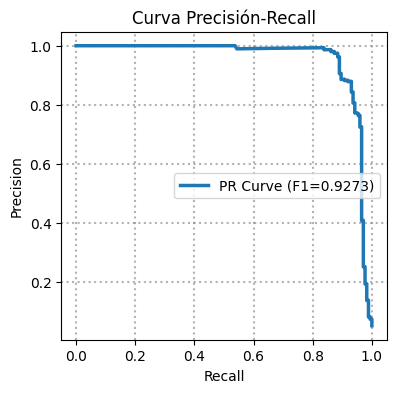

F1 score en el conjunto de TEST = 0.9273


In [50]:
# ============================================================
# CURVA PRECISIÓN-RECALL (requerida por el enunciado)
# ============================================================
precision_test, recall_test, th = precision_recall_curve(Y_test, probs_best)

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot()
ax.set_aspect('equal', adjustable='box')

plt.plot(recall_test, precision_test, lw=2.5, label=f'PR Curve (F1={F1_score_test:.4f})')
plt.legend(loc=7)
plt.grid(which='major', color='gray', alpha=0.6, linestyle='dotted', lw=1.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precisión-Recall')
plt.show()

print(f"F1 score en el conjunto de TEST = {F1_score_test:.4f}")

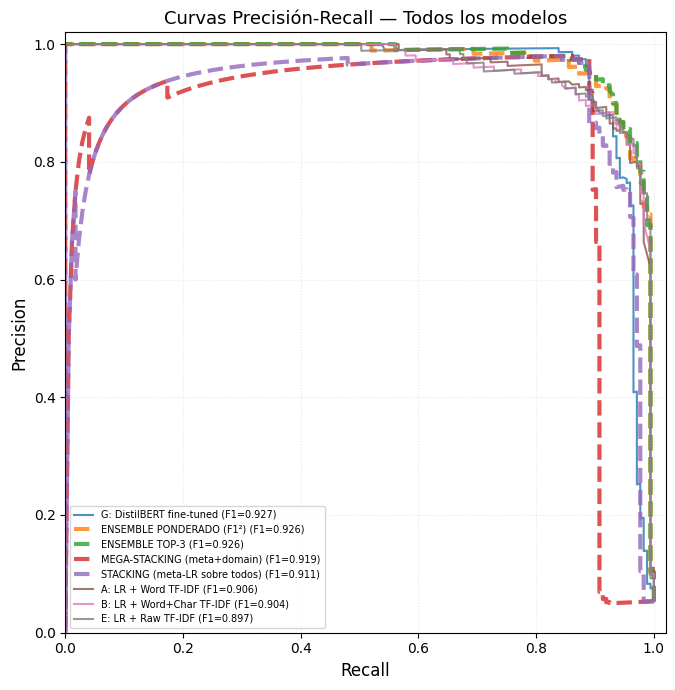

In [51]:
# ============================================================
# CURVAS PR COMPARATIVAS DE TODOS LOS MODELOS
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_aspect('equal', adjustable='box')

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for idx, r in enumerate(sorted(ALL_RESULTS, key=lambda x: x['f1'], reverse=True)[:8]):
    if r['probs'] is not None:
        p, rec, _ = precision_recall_curve(Y_test, r['probs'])
        lw = 3 if 'STACK' in r['name'] or 'ENSEMBLE' in r['name'] else 1.5
        ls = '--' if 'STACK' in r['name'] or 'ENSEMBLE' in r['name'] else '-'
        ax.plot(rec, p, lw=lw, linestyle=ls,
                label=f"{r['name'][:38]} (F1={r['f1']:.3f})",
                color=colors[idx], alpha=0.8)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curvas Precisión-Recall — Todos los modelos', fontsize=13)
ax.legend(loc='lower left', fontsize=7)
ax.grid(alpha=0.3, linestyle='dotted')
ax.set_xlim([0, 1.02])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

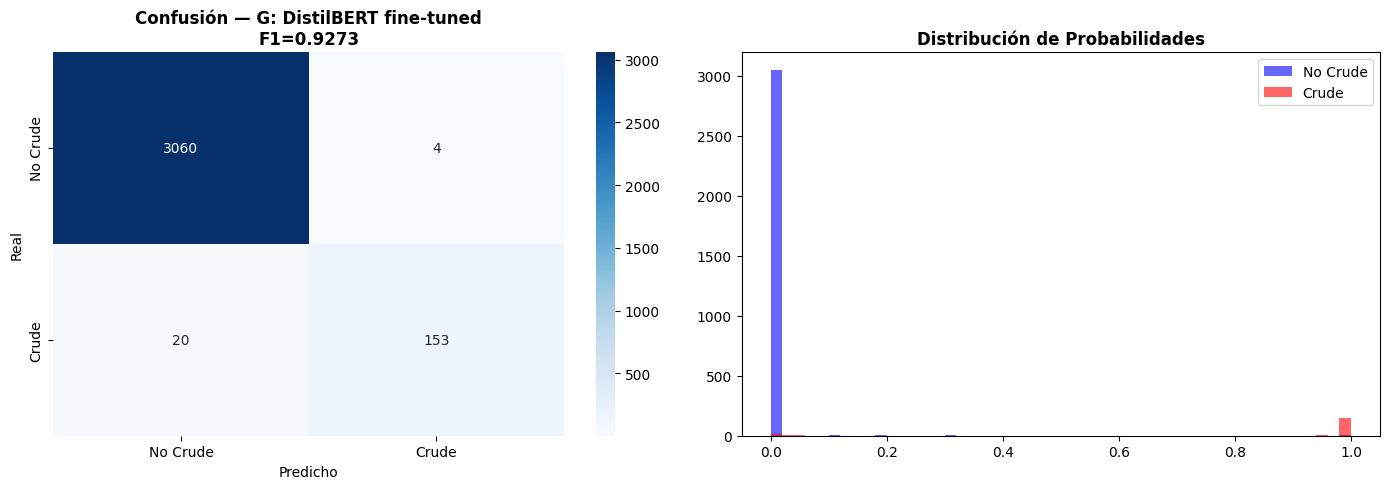

Falsos Negativos (crude no detectados): 20
Falsos Positivos (no crude → crude):    4
Total errores: 24 de 3237


In [52]:
# ============================================================
# MATRIZ DE CONFUSIÓN + ANÁLISIS DE ERRORES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(Y_test, preds_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Crude', 'Crude'], yticklabels=['No Crude', 'Crude'],
            ax=axes[0])
axes[0].set_title(f'Confusión — {best_result["name"]}\nF1={F1_score_test:.4f}', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Distribución de probabilidades
axes[1].hist(probs_best[Y_test == 0], bins=50, alpha=0.6, label='No Crude', color='blue')
axes[1].hist(probs_best[Y_test == 1], bins=50, alpha=0.6, label='Crude', color='red')
axes[1].set_title('Distribución de Probabilidades', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Análisis de errores
fn = (Y_test == 1) & (preds_test == 0)
fp = (Y_test == 0) & (preds_test == 1)
print(f"Falsos Negativos (crude no detectados): {fn.sum()}")
print(f"Falsos Positivos (no crude → crude):    {fp.sum()}")
print(f"Total errores: {fn.sum() + fp.sum()} de {len(Y_test)}")

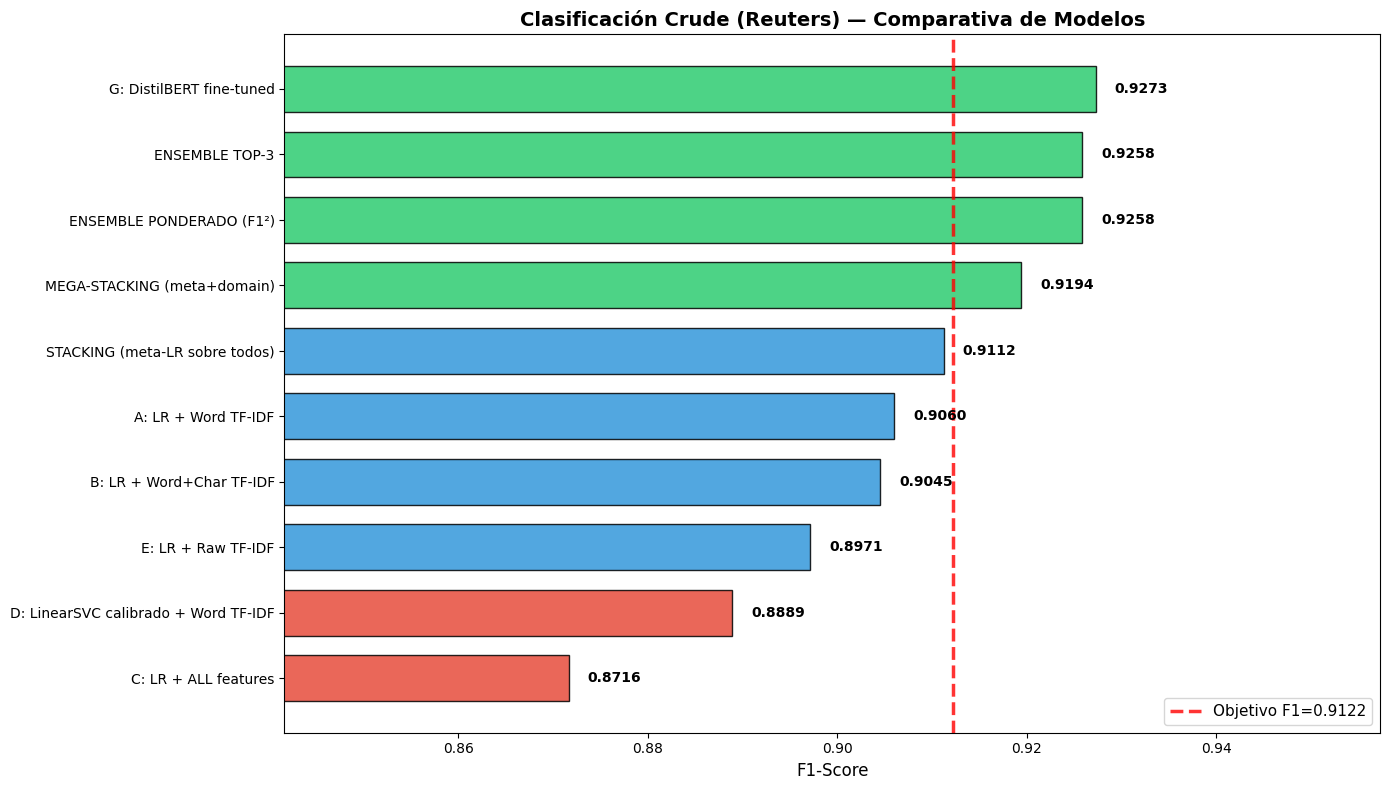

In [53]:
# ============================================================
# GRÁFICO BARRAS COMPARATIVO
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))

sorted_r = sorted(ALL_RESULTS, key=lambda x: x['f1'])
names = [r['name'] for r in sorted_r]
f1s = [r['f1'] for r in sorted_r]
colors = ['#2ecc71' if f > 0.9122 else '#3498db' if f > 0.89 else '#e74c3c' for f in f1s]

bars = ax.barh(names, f1s, color=colors, edgecolor='black', alpha=0.85, height=0.7)
ax.axvline(x=0.9122, color='red', linestyle='--', linewidth=2.5, 
           label='Objetivo F1=0.9122', alpha=0.8)

for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{f1:.4f}', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Clasificación Crude (Reuters) — Comparativa de Modelos', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim(min(f1s) - 0.03, max(f1s) + 0.03)
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# CLASSIFICATION REPORT FINAL 
# ============================================================
print(f"\n{'='*60}")
print(f"RESULTADO FINAL: {best_result['name']}")
print(f"{'='*60}")
print(f"\nF1 score en el conjunto de TEST = {F1_score_test:.4f}")
print(f"\n{classification_report(Y_test, preds_test, target_names=['No Crude', 'Crude'])}")


RESULTADO FINAL: G: DistilBERT fine-tuned

F1 score en el conjunto de TEST = 0.9273

              precision    recall  f1-score   support

    No Crude       0.99      1.00      1.00      3064
       Crude       0.97      0.88      0.93       173

    accuracy                           0.99      3237
   macro avg       0.98      0.94      0.96      3237
weighted avg       0.99      0.99      0.99      3237



Gracias por todo lo que he aprendido con este proyecto más como reto personal de intentar llegar al máximo